In [1]:
import numpy as np
import pandas as pd
import lasio as las
from glob import glob
import matplotlib.pyplot as plt
import torch as pt
import gpytorch
import scipy
import os

from util.filehandler import read_las
from util.plotting import plot_well_logs
from util.well_processing import filter_wells_by_lithology, prepare_valid_tagilsk
from util.gaussian_processes import fit_gp_model_all_wells, predict_gp_model

In [2]:
las_files = glob('/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/*Tgl*.las')
las_files

['/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-30.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-26.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/ZTgl-1.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-15.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-29.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-8.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=docume

In [3]:
# Create a dictionary to store all DataFrames
las_dfs = read_las(las_files)
# Keep only needed curves
las_dfs = prepare_valid_tagilsk(las_dfs)
# Display the keys (well names) in the dictionary
# del las_dfs['ZTgl-1']
print(f"\nTotal wells loaded: {len(las_dfs)}")
print(f"Well names: {list(las_dfs.keys())}")

Loaded: Tgl-30 - 4603 rows, 14 curves
Loaded: Tgl-26 - 6062 rows, 15 curves
Loaded: ZTgl-1 - 5408 rows, 12 curves
Loaded: Tgl-15 - 5898 rows, 14 curves
Loaded: Tgl-29 - 29873 rows, 14 curves
Loaded: Tgl-8 - 7623 rows, 16 curves
Loaded: Tgl-27 - 2377 rows, 12 curves
Processing well Tgl-30
Processing well Tgl-26
Processing well ZTgl-1
Processing well Tgl-15
Processing well Tgl-29
Processing well Tgl-8
Processing well Tgl-27

Total wells loaded: 7
Well names: ['Tgl-30', 'Tgl-26', 'ZTgl-1', 'Tgl-15', 'Tgl-29', 'Tgl-8', 'Tgl-27']


## Processing wells, deleting trash data

In [ ]:
# Manual trash data deletion
# Tgl-29
mask = (las_dfs['Tgl-29']['DEPTH'] < 3700) & (las_dfs['Tgl-29']['DEPTH'] > 3000)
las_dfs['Tgl-29'].loc[mask, 'DTP'] = np.nan
mask = (las_dfs['Tgl-29']['DEPTH'] < 3700) & (las_dfs['Tgl-29']['DEPTH'] > 2398)
las_dfs['Tgl-29'].loc[mask, 'DTS'] = np.nan
# ZTgl-1
mask = (las_dfs['ZTgl-1']['DEPTH'] < 3150) & (las_dfs['ZTgl-1']['DEPTH'] > 2964)
las_dfs['ZTgl-1'].loc[mask, 'PL_GG'] = np.nan

In [55]:
test = las_dfs['ZTgl-1'][
    (las_dfs['ZTgl-1']['DEPTH'] < 3150) & 
    (las_dfs['ZTgl-1']['DEPTH'] > 2964)
]

In [19]:
las_dfs['Tgl-29'].keys()

Index(['DEPTH', 'LITH', 'NAS', 'PL_GG', 'DTP', 'DTS', 'VP', 'VP_LOG', 'VS',
       'VS_LOG'],
      dtype='str')

(<Figure size 850x1200 with 5 Axes>,
 array([<Axes: title={'center': 'NAS'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'LITH'}>, <Axes: title={'center': 'DTP'}>,
        <Axes: title={'center': 'DTS'}>, <Axes: title={'center': 'PL_GG'}>],
       dtype=object))

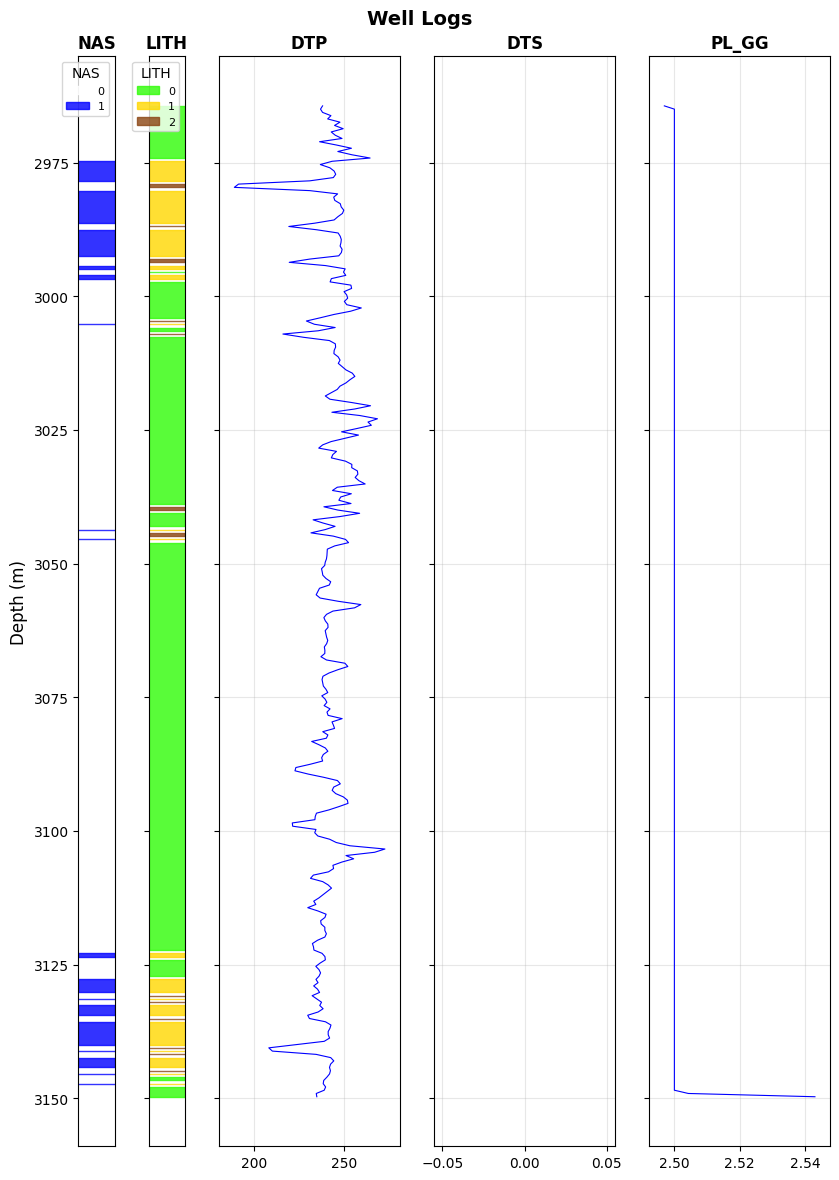

In [56]:
plot_well_logs(test, ['NAS', 'LITH', 'DTP', 'DTS', 'PL_GG'])

In [6]:
las_dfs_shale = {}
las_dfs_brine_sand = {}
las_dfs_oil_sand = {}
las_dfs_gas_sand = {}

# Apply filtering to all wells
las_dfs_shale, las_dfs_brine_sand, las_dfs_oil_sand, las_dfs_gas_sand = filter_wells_by_lithology(las_dfs)

Tgl-30: shale=2260, brine=1707, oil=142, gas=4
Tgl-26: shale=2806, brine=2255, oil=446, gas=94
ZTgl-1: shale=2184, brine=2217, oil=0, gas=0
Tgl-15: shale=2430, brine=1939, oil=427, gas=285
Tgl-29: shale=15536, brine=12102, oil=1081, gas=194
Tgl-8: shale=3158, brine=723, oil=1774, gas=55
Tgl-27: shale=848, brine=46, oil=215, gas=34


# Probabalistic models implementation

VP: R² = 0.957, kernel = 0.888**2 * RBF(length_scale=2.45) + WhiteKernel(noise_level=0.0629)


<Axes: title={'center': 'GP Model: VP'}, xlabel='Depth (m)', ylabel='VP'>

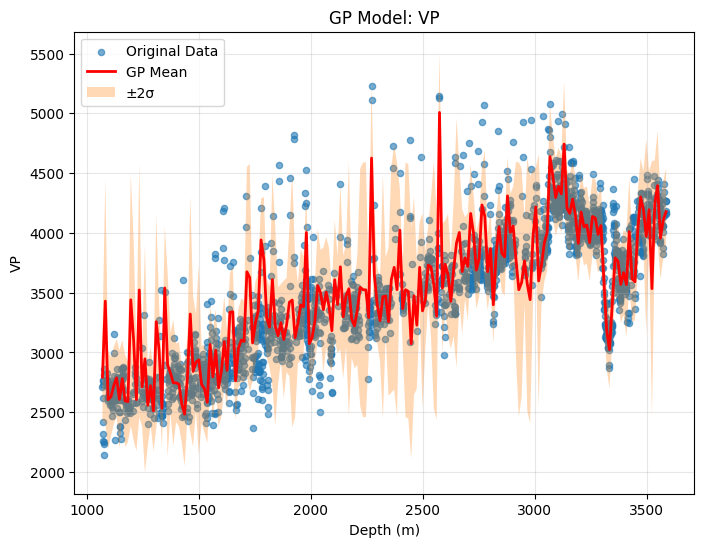

In [7]:
from util.gaussian_processes_sklearn import fit_gp_model_sklearn
from util.plotting import plot_gp_model

result = fit_gp_model_sklearn(las_dfs_shale['Tgl-30'], 'VP')
plot_gp_model(result, 'VP')

In [8]:
pt.cuda.is_available()

True

In [9]:
las_dfs_shale.keys()

dict_keys(['Tgl-30', 'Tgl-26', 'ZTgl-1', 'Tgl-15', 'Tgl-29', 'Tgl-8', 'Tgl-27'])

In [17]:
result_shale = fit_gp_model_all_wells(
    las_dfs_shale,
    property_col='VS',
    max_points=10000,
    training_iter=100,
    lengthscale=0.1
)

Using 29222 total points for VS
VS: subsampled to 10000 points
VS: trained on 10000 points


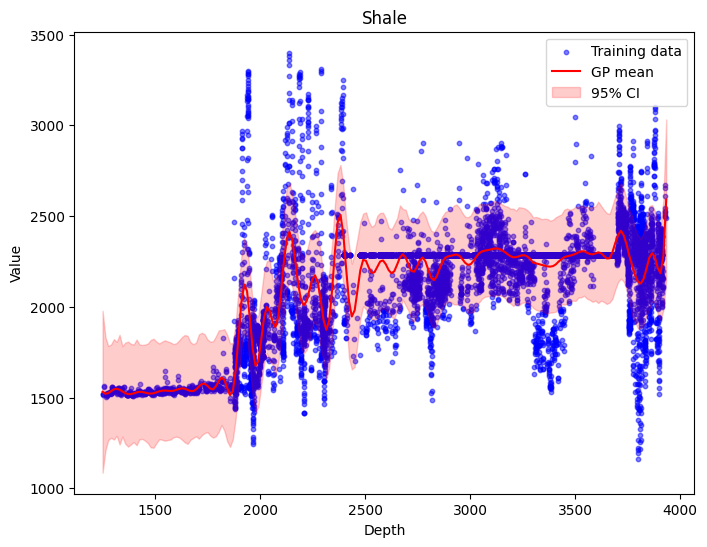

In [18]:
def plot_gp_result(gp_result: dict, x_train: np.ndarray, y_train: np.ndarray, title: str = None):
    """
    Simple plot of GP results with training data and uncertainty.
    
    Parameters
    ----------
    gp_result : dict
        Result from fit_gp_model()
    x_train : array
        Training depth values
    y_train : array
        Training property values
    title : str, optional
        Plot title
    """
    # Predict on smooth range
    x_range = np.linspace(gp_result['depth_range'][0], gp_result['depth_range'][1], 200)
    mean, std = predict_gp_model(gp_result, x_range)
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(x_train, y_train, c='blue', s=10, alpha=0.5, label='Training data')
    plt.plot(x_range, mean, 'r-', label='GP mean')
    plt.fill_between(x_range, mean - 2*std, mean + 2*std, alpha=0.2, color='red', label='95% CI')
    plt.xlabel('Depth')
    plt.ylabel('Value')
    if title:
        plt.title(title)
    plt.legend()
    plt.show()
all_data = []
    
for well_name, df in las_dfs_shale.items():
    app_data = df[['DEPTH', 'VS']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
plot_gp_result(result_shale, combined_df['DEPTH'], combined_df['VS'], title='Shale')

In [17]:
combined_df[combined_df['DEPTH'] < 1072]

,DEPTH,VP_LOG
0,1070.887207,7.904103
1,1071.496826,7.921979
2260,1024.300049,7.808040
2261,1024.800049,7.825510
2262,1025.300049,7.813957
...,...,...
28406,1068.157227,7.789955
28407,1068.766846,7.781197
28408,1069.376343,7.757871
28409,1069.985962,7.752119


In [27]:
result_shale['likelihood'].noise.item()

0.3087446689605713

In [28]:
# Check what the model learned
result = result_shale['likelihood']
model = result_shale['model']

print("Model hyperparameters:")
print(f"  Lengthscale: {model.covar_module.base_kernel.lengthscale.item():.2f}")
print(f"  Output scale: {model.covar_module.outputscale.item():.2f}")
print(f"  Noise: {result.noise.item():.6f}")
print(f"  Mean constant: {model.mean_module.constant.item():.2f}")

Model hyperparameters:
  Lengthscale: 0.01
  Output scale: 4.19
  Noise: 0.308745
  Mean constant: -0.86


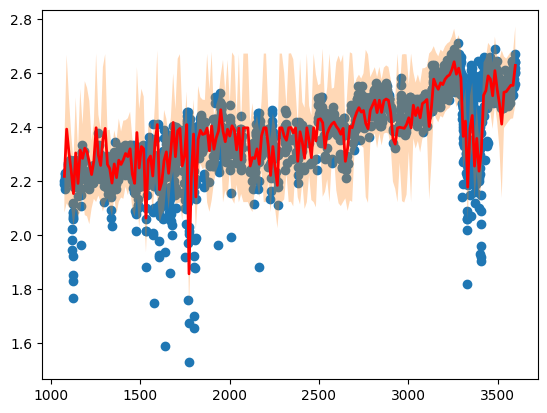

In [ ]:
x = las_dfs_shale['Tgl-15']['DEPTH']
y = las_dfs_shale['Tgl-15']['PL_GG']
x_smooth = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_mean, y_std = result['model'].predict(x_smooth, return_std=True)
plt.scatter(x, y)
plt.plot(x_smooth, y_mean, 'r-', label='GP Mean', linewidth=2)
plt.fill_between(x_smooth.flatten(), 
                y_mean - 2*y_std, 
                y_mean + 2*y_std, 
                alpha=0.3, label='±2σ')


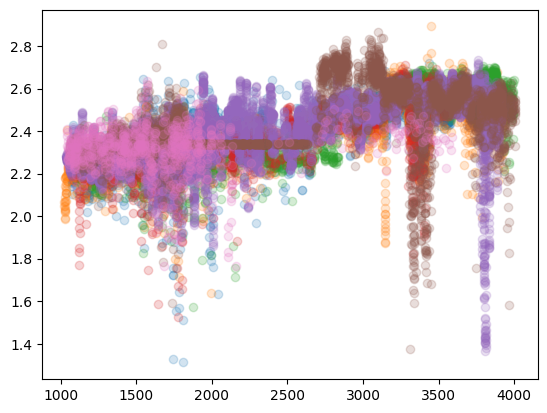

In [ ]:
for well in las_dfs_shale.keys():
    x = las_dfs_shale[well]['DEPTH']
    y = las_dfs_shale[well]['PL_GG']
    plt.scatter(x, y, alpha=0.2)